SINGLE-PERIOD RESULTS (Adolescent Window)
Terminal π₃(Π=0): [0.695  0.2175 0.0875 0.    ]
Terminal π₃(Π>0): [0.7575 0.1745 0.0505 0.0175]
E[Crime|Π=0] = 0.0532 (5.32%)
E[Crime|Π>0] = 0.0426 (4.26%)
Reduction: 1.06 pp (19.9%)

Treatment pathway: -0.8375 pp (79.3%)
Prevention pathway: -0.2190 pp (20.7%)

Fundamental matrix F:
[[9.3333 4.    ]
 [2.6667 4.    ]]
Expected windows to absorption: H=13.33, R=6.67

Stationary distribution (with Medicaid): [0.6656 0.2208 0.0757 0.0379]


/tmp/ipykernel_3365/2841827057.py:150: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), 0.3, color=color, alpha=alpha,


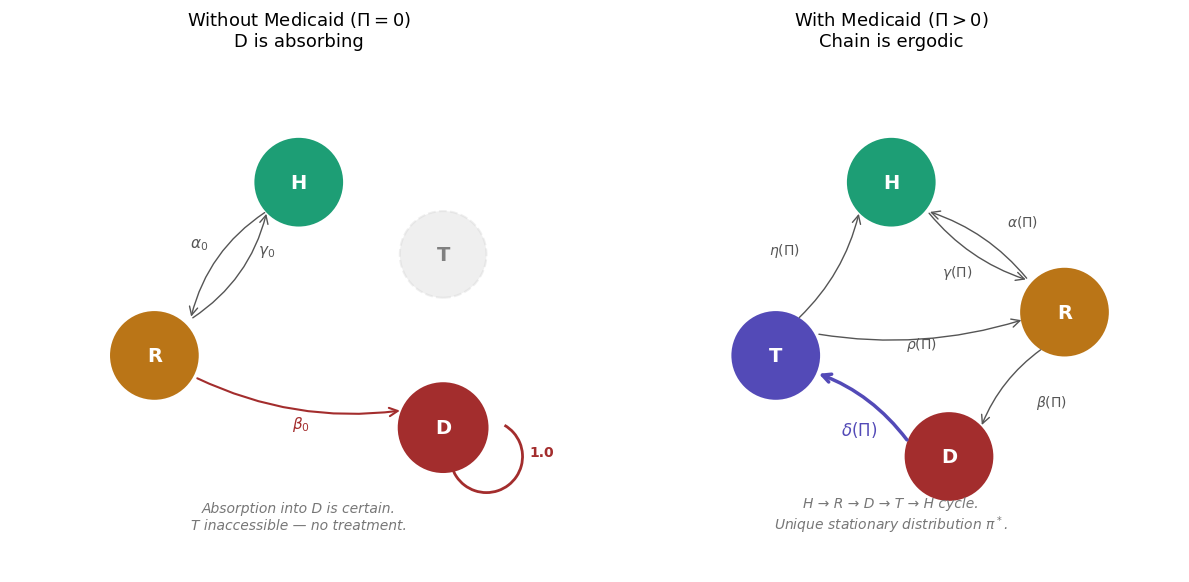

Figure 4 saved.


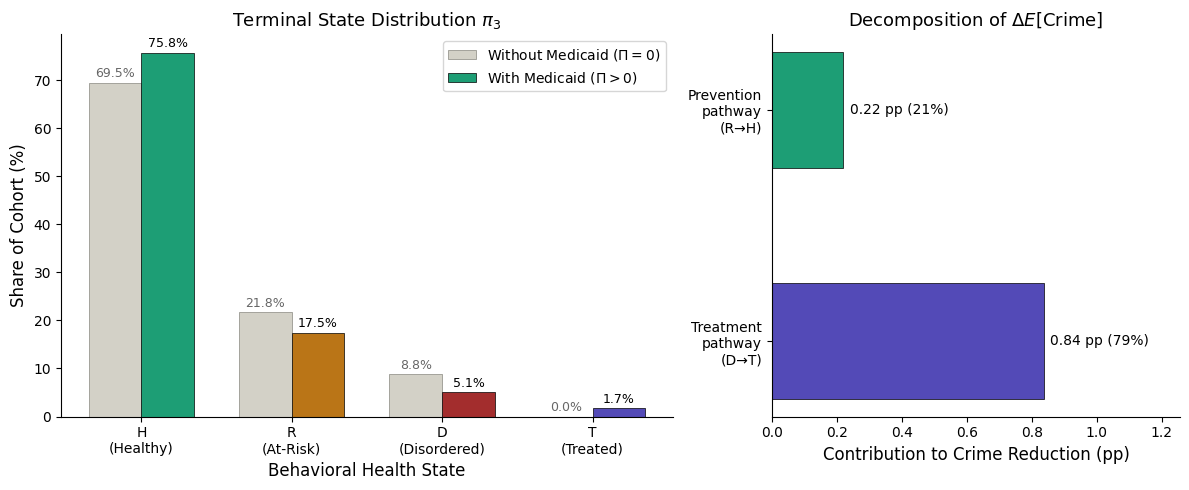

Figure 5 saved.

COMPLETE NUMERICAL RESULTS FOR SECTION 3.2.5

Entry distribution: π₂ = [0.8  0.15 0.05 0.  ]

Without Medicaid:
  π₃(0) = (0.695, 0.217, 0.087, 0.000)
  E[Crime] = 5.32%

With Medicaid:
  π₃(Π) = (0.758, 0.175, 0.051, 0.017)
  E[Crime] = 4.26%

Crime reduction: 1.06 pp (19.9%)

Decomposition:
  Treatment pathway: 0.8375 pp (79.3%)
  Prevention pathway: 0.2190 pp (20.7%)

Absorbing chain (Π=0):
  Fundamental matrix F = 
[[9.3333 4.    ]
 [2.6667 4.    ]]
  Expected windows to absorption: H→D = 13.33, R→D = 6.67

Stationary distribution (Π>0): π* = (0.6656, 0.2208, 0.0757, 0.0379)
  E[Crime] at stationarity = 5.18%


In [ ]:
"""
Behavioral Health Dynamics Model — Figures and Computations
Section 3.2 of "Insuring Against Crime"

Run in Google Colab. Generates:
  - Figure 4: State transition diagrams (with and without Medicaid)
  - Figure 5: Terminal distributions and crime decomposition
  - All numerical results for the text
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# =============================================================
# MODEL PARAMETERS
# =============================================================

# Initial distribution at birth
pi_birth = np.array([1.0, 0.0, 0.0, 0.0])  # H, R, D, T
state_labels = ['H', 'R', 'D', 'T']
state_names = ['Healthy', 'At-Risk', 'Disordered', 'Treated']

# Crime propensities per state
c = np.array([0.02, 0.08, 0.25, 0.05])

# --- Transition matrices by developmental window ---

# Ages 0-5: Low onset, minimal Medicaid effect
P_05_no = np.array([
    [0.95, 0.05, 0.00, 0.00],
    [0.15, 0.70, 0.15, 0.00],
    [0.00, 0.00, 1.00, 0.00],
    [0.00, 0.00, 0.00, 0.00],  # T inaccessible
])
P_05_med = np.array([
    [0.96, 0.04, 0.00, 0.00],
    [0.20, 0.68, 0.10, 0.00],
    [0.00, 0.00, 0.85, 0.15],
    [0.40, 0.40, 0.00, 0.20],
])

# Ages 6-11: Some onset, healthcare connections established
P_611_no = np.array([
    [0.90, 0.10, 0.00, 0.00],
    [0.10, 0.65, 0.25, 0.00],
    [0.00, 0.00, 1.00, 0.00],
    [0.00, 0.00, 0.00, 0.00],
])
P_611_med = np.array([
    [0.93, 0.07, 0.00, 0.00],
    [0.20, 0.65, 0.10, 0.05],
    [0.00, 0.00, 0.70, 0.30],
    [0.35, 0.40, 0.00, 0.25],
])

# Ages 12-18: High onset, Medicaid effect strongest
P_1218_no = np.array([
    [0.85, 0.15, 0.00, 0.00],
    [0.10, 0.65, 0.25, 0.00],
    [0.00, 0.00, 1.00, 0.00],
    [0.00, 0.00, 0.00, 0.00],
])
P_1218_med = np.array([
    [0.90, 0.10, 0.00, 0.00],
    [0.25, 0.63, 0.12, 0.00],
    [0.00, 0.00, 0.65, 0.35],
    [0.30, 0.40, 0.00, 0.30],
])


# =============================================================
# COMPUTATIONS
# =============================================================

def compute_trajectory(pi0, P1, P2, P3):
    """Compute state distribution trajectory across 3 developmental windows."""
    pi1 = pi0 @ P1
    pi2 = pi1 @ P2
    pi3 = pi2 @ P3
    return pi0, pi1, pi2, pi3

def compute_stationary(P):
    """Solve pi*P = pi for the stationary distribution."""
    A = P.T - np.eye(4)
    A[-1, :] = 1
    b = np.zeros(4)
    b[-1] = 1
    return np.linalg.solve(A, b)

def fundamental_matrix(P_no_med):
    """Compute fundamental matrix for absorbing chain (D absorbing)."""
    Q = P_no_med[:2, :2]
    R_abs = P_no_med[:2, 2:3]
    I_Q = np.eye(2) - Q
    F = np.linalg.inv(I_Q)
    absorption_time = F @ np.ones(2)
    return F, absorption_time

# Single-period (adolescent window only)
pi2_entry = np.array([0.80, 0.15, 0.05, 0.00])
pi3_no = pi2_entry @ P_1218_no
pi3_med = pi2_entry @ P_1218_med

E_no = pi3_no @ c
E_med = pi3_med @ c

# Decomposition
delta_pi = pi3_med - pi3_no
contributions = delta_pi * c
treatment_pathway = contributions[2] + contributions[3]
prevention_pathway = contributions[0] + contributions[1]
total = contributions.sum()

# Full lifecycle
_, _, _, pi3_full_no = compute_trajectory(pi_birth, P_05_no, P_611_no, P_1218_no)
_, _, _, pi3_full_med = compute_trajectory(pi_birth, P_05_med, P_611_med, P_1218_med)

# Fundamental matrix
F, abs_time = fundamental_matrix(P_1218_no)

# Stationary distribution (with Medicaid)
pi_star = compute_stationary(P_1218_med)

# Print all results
print("=" * 60)
print("SINGLE-PERIOD RESULTS (Adolescent Window)")
print("=" * 60)
print(f"Terminal π₃(Π=0): {np.round(pi3_no, 4)}")
print(f"Terminal π₃(Π>0): {np.round(pi3_med, 4)}")
print(f"E[Crime|Π=0] = {E_no:.4f} ({E_no*100:.2f}%)")
print(f"E[Crime|Π>0] = {E_med:.4f} ({E_med*100:.2f}%)")
print(f"Reduction: {(E_no-E_med)*100:.2f} pp ({(E_no-E_med)/E_no*100:.1f}%)")
print(f"\nTreatment pathway: {treatment_pathway*100:.4f} pp ({treatment_pathway/total*100:.1f}%)")
print(f"Prevention pathway: {prevention_pathway*100:.4f} pp ({prevention_pathway/total*100:.1f}%)")
print(f"\nFundamental matrix F:\n{np.round(F, 4)}")
print(f"Expected windows to absorption: H={abs_time[0]:.2f}, R={abs_time[1]:.2f}")
print(f"\nStationary distribution (with Medicaid): {np.round(pi_star, 4)}")


# =============================================================
# FIGURE 4: STATE TRANSITION DIAGRAMS
# =============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

def draw_state_circle(ax, x, y, label, color, alpha=1.0, linewidth=1.5,
                      linestyle='-', textcolor='white'):
    circle = plt.Circle((x, y), 0.3, color=color, alpha=alpha,
                        linewidth=linewidth, linestyle=linestyle,
                        edgecolor='black' if alpha > 0.5 else 'gray')
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', fontsize=14,
            fontweight='bold', color=textcolor if alpha > 0.5 else 'gray')

def draw_arrow(ax, x1, y1, x2, y2, label='', color='black',
               linewidth=1.0, connectionstyle='arc3,rad=0.15'):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            connectionstyle=connectionstyle,
                            arrowstyle='->', mutation_scale=15,
                            color=color, linewidth=linewidth)
    ax.add_patch(arrow)

# Colors
col_H = '#1D9E75'   # Teal
col_R = '#BA7517'    # Amber
col_D = '#A32D2D'    # Red
col_T = '#534AB7'    # Purple

# --- Panel A: Without Medicaid ---
ax1.set_xlim(-1.5, 2.5)
ax1.set_ylim(-1.5, 2.0)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Without Medicaid ($\\Pi = 0$)\nD is absorbing', fontsize=13, pad=15)

# State positions (panel A)
pos_A = {'H': (0.5, 1.2), 'R': (-0.5, 0.0), 'D': (1.5, -0.5), 'T': (1.5, 0.7)}

draw_state_circle(ax1, *pos_A['H'], 'H', col_H)
draw_state_circle(ax1, *pos_A['R'], 'R', col_R)
draw_state_circle(ax1, *pos_A['D'], 'D', col_D, linewidth=3.0)  # Thick = absorbing
draw_state_circle(ax1, *pos_A['T'], 'T', '#CCCCCC', alpha=0.3, linestyle='--',
                  textcolor='gray')

# Arrows
draw_arrow(ax1, 0.28, 1.0, -0.25, 0.25, connectionstyle='arc3,rad=0.2',
           color='#555555')
ax1.text(-0.25, 0.75, '$\\alpha_0$', fontsize=11, color='#555555')

draw_arrow(ax1, -0.25, 0.25, 0.28, 1.0, connectionstyle='arc3,rad=0.2',
           color='#555555')
ax1.text(0.22, 0.70, '$\\gamma_0$', fontsize=11, color='#555555')

draw_arrow(ax1, -0.22, -0.15, 1.22, -0.38, connectionstyle='arc3,rad=0.15',
           color=col_D, linewidth=1.5)
ax1.text(0.45, -0.50, '$\\beta_0$', fontsize=11, color=col_D)

# D self-loop
from matplotlib.patches import Arc
self_loop = Arc((1.8, -0.7), 0.5, 0.5, angle=0, theta1=120, theta2=420,
                color=col_D, linewidth=2.0)
ax1.add_patch(self_loop)
ax1.text(2.1, -0.7, '1.0', fontsize=10, color=col_D, fontweight='bold')

ax1.text(0.5, -1.2, 'Absorption into D is certain.\nT inaccessible — no treatment.',
         ha='center', fontsize=10, color='#777777', style='italic')

# --- Panel B: With Medicaid ---
ax2.set_xlim(-1.5, 2.5)
ax2.set_ylim(-1.5, 2.0)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('With Medicaid ($\\Pi > 0$)\nChain is ergodic', fontsize=13, pad=15)

# State positions (panel B) — diamond arrangement
pos_B = {'H': (0.5, 1.2), 'R': (1.7, 0.3), 'D': (0.9, -0.7), 'T': (-0.3, 0.0)}

draw_state_circle(ax2, *pos_B['H'], 'H', col_H)
draw_state_circle(ax2, *pos_B['R'], 'R', col_R)
draw_state_circle(ax2, *pos_B['D'], 'D', col_D)
draw_state_circle(ax2, *pos_B['T'], 'T', col_T)

# H→R
draw_arrow(ax2, 0.75, 1.0, 1.45, 0.52, connectionstyle='arc3,rad=0.15',
           color='#555555')
ax2.text(1.30, 0.90, '$\\alpha(\\Pi)$', fontsize=10, color='#555555')

# R→H
draw_arrow(ax2, 1.45, 0.52, 0.75, 1.0, connectionstyle='arc3,rad=0.15',
           color='#555555')
ax2.text(0.85, 0.55, '$\\gamma(\\Pi)$', fontsize=10, color='#555555')

# R→D
draw_arrow(ax2, 1.55, 0.05, 1.12, -0.50, connectionstyle='arc3,rad=0.15',
           color='#555555')
ax2.text(1.50, -0.35, '$\\beta(\\Pi)$', fontsize=10, color='#555555')

# D→T (THE KEY — highlighted)
draw_arrow(ax2, 0.62, -0.60, -0.02, -0.12, connectionstyle='arc3,rad=0.15',
           color=col_T, linewidth=2.5)
ax2.text(0.15, -0.55, '$\\delta(\\Pi)$', fontsize=12, color=col_T,
         fontweight='bold')

# T→H
draw_arrow(ax2, -0.15, 0.25, 0.28, 1.0, connectionstyle='arc3,rad=0.15',
           color='#555555')
ax2.text(-0.35, 0.70, '$\\eta(\\Pi)$', fontsize=10, color='#555555')

# T→R
draw_arrow(ax2, -0.02, 0.15, 1.42, 0.25, connectionstyle='arc3,rad=0.12',
           color='#555555')
ax2.text(0.60, 0.05, '$\\rho(\\Pi)$', fontsize=10, color='#555555')

ax2.text(0.5, -1.2, 'H → R → D → T → H cycle.\nUnique stationary distribution $\\pi^*$.',
         ha='center', fontsize=10, color='#777777', style='italic')

plt.tight_layout()
plt.savefig('figure4_state_transitions.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figure4_state_transitions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")


# =============================================================
# FIGURE 5: TERMINAL DISTRIBUTIONS AND DECOMPOSITION
# =============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 2]})

# --- Panel A: Terminal Distributions ---
x = np.arange(4)
width = 0.35

bars1 = ax1.bar(x - width/2, pi3_no * 100, width, label='Without Medicaid ($\\Pi=0$)',
                color='#D3D1C7', edgecolor='#888780', linewidth=0.5)
bars2 = ax1.bar(x + width/2, pi3_med * 100, width, label='With Medicaid ($\\Pi>0$)',
                color=[col_H, col_R, col_D, col_T], edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Behavioral Health State', fontsize=12)
ax1.set_ylabel('Share of Cohort (%)', fontsize=12)
ax1.set_title('Terminal State Distribution $\\pi_3$', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(['H\n(Healthy)', 'R\n(At-Risk)', 'D\n(Disordered)', 'T\n(Treated)'],
                     fontsize=10)
ax1.legend(fontsize=10, loc='upper right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9, color='#666666')
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# --- Panel B: Crime Decomposition ---
pathways = ['Treatment\npathway\n(D→T)', 'Prevention\npathway\n(R→H)']
values = [abs(treatment_pathway) * 100, abs(prevention_pathway) * 100]
pcts = [f'{abs(treatment_pathway/total)*100:.0f}%', f'{abs(prevention_pathway/total)*100:.0f}%']
colors = [col_T, col_H]

bars = ax2.barh(pathways, values, color=colors, edgecolor='black', linewidth=0.5, height=0.5)
ax2.set_xlabel('Contribution to Crime Reduction (pp)', fontsize=12)
ax2.set_title('Decomposition of $\\Delta E[\\text{Crime}]$', fontsize=13)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar, pct in zip(bars, pcts):
    w = bar.get_width()
    ax2.text(w + 0.02, bar.get_y() + bar.get_height()/2.,
             f'{w:.2f} pp ({pct})', ha='left', va='center', fontsize=10)

ax2.set_xlim(0, max(values) * 1.5)

plt.tight_layout()
plt.savefig('figure5_distributions_decomposition.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figure5_distributions_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")


# =============================================================
# PRINT ALL RESULTS FOR TEXT
# =============================================================
print("\n" + "=" * 60)
print("COMPLETE NUMERICAL RESULTS FOR SECTION 3.2.5")
print("=" * 60)
print(f"\nEntry distribution: π₂ = {pi2_entry}")
print(f"\nWithout Medicaid:")
print(f"  π₃(0) = ({', '.join(f'{x:.3f}' for x in pi3_no)})")
print(f"  E[Crime] = {E_no*100:.2f}%")
print(f"\nWith Medicaid:")
print(f"  π₃(Π) = ({', '.join(f'{x:.3f}' for x in pi3_med)})")
print(f"  E[Crime] = {E_med*100:.2f}%")
print(f"\nCrime reduction: {(E_no-E_med)*100:.2f} pp ({(E_no-E_med)/E_no*100:.1f}%)")
print(f"\nDecomposition:")
print(f"  Treatment pathway: {abs(treatment_pathway)*100:.4f} pp ({abs(treatment_pathway/total)*100:.1f}%)")
print(f"  Prevention pathway: {abs(prevention_pathway)*100:.4f} pp ({abs(prevention_pathway/total)*100:.1f}%)")
print(f"\nAbsorbing chain (Π=0):")
print(f"  Fundamental matrix F = \n{np.round(F, 4)}")
print(f"  Expected windows to absorption: H→D = {abs_time[0]:.2f}, R→D = {abs_time[1]:.2f}")
print(f"\nStationary distribution (Π>0): π* = ({', '.join(f'{x:.4f}' for x in pi_star)})")
print(f"  E[Crime] at stationarity = {(pi_star @ c)*100:.2f}%")